# 12j — Stage-1 NUTS chain convergence, at one forecast origin

Stage 1 became a **NUTS** fit on 2026-08-05 (`cfg.stage1_use_nuts`, initialised from the Pathfinder mean). The entire reason to pay for NUTS over Pathfinder is that its draws are asymptotically exact rather than a Gaussian approximation — which buys nothing unless the chain actually converged. This notebook is the per-origin audit of that claim, for **both** Stage-1 degree models:

| axis | value |
|---|---|
| degree models | `unweighted-negbin` (389 latents) · `weighted-hweibull` (977 latents) |
| origin | one forecast origin, horizon `h = 1` |
| sampler | NUTS, 1000 adapt + 500 kept, `target_accept = 0.95`, `max_depth = 10` |
| AD | Mooncake (`cfg.ad_backend`) |

The NGM axis does **not** appear: Stage 1 is NGM-independent (it returns raw moments `(; K1, K2, G)`, and the builder is applied downstream by `contact_star`), so these two chains are *all* of Stage 1 for this origin.

## ⚠ One chain per fit — read the diagnostics accordingly

`prefit_stage1!` fans 504 fits out over threads, so each fit runs a **single** chain and there is no between-chain R̂ (see `_nuts_diagnostics`). Everything below therefore uses **rank-normalised split-R̂** (Vehtari et al. 2021): `MCMCDiagnosticTools` defaults to `split_chains = 2`, so R̂ on one chain compares its own two halves.

That is a real diagnostic — it detects a chain that has not reached stationarity — but it is strictly weaker than the multi-chain version: **it cannot detect two chains stuck in different modes.** A clean split-R̂ here means *"this chain is stationary"*, never *"the posterior was explored"*.

Thresholds are the modern rank-normalised ones (**R̂ < 1.01, ESS ≥ 100**), which are stricter than the `ESS > 200 / R̂ < 1.1` rule in `turing_utils.jl` — that rule predates this strand and was written for the multi-chain distribution fits.

In [1]:
ENV["GKSwstype"] = "100"   # headless GR (off-screen PNG) for nbconvert
include("forecast_utils.jl")   # single preamble: base + CoMix pipeline + forecasting framework
include("8j_viz_utils.jl")     # stage1_chain_path — the production-cache fallback
include("12j_viz_utils.jl")    # load_nuts_chain, convergence_table/summary, hmc_health, figures
using Random, Statistics, DataFrames, Printf
mkpath("../res")

default_plot_setting()

Plots.GRBackend()

In [2]:
cfg    = FrameworkConfig(constant_contacts = false)   # production defaults: NUTS + Mooncake
# One origin per execution — the audit below is a single-origin narrative. Set ORIGIN_12J to run
# it over another origin without editing the notebook; every ../res figure name embeds the origin,
# so repeated executions accumulate rather than overwrite.
ORIGIN = Date(get(ENV, "ORIGIN_12J", "2021-05-09"))
H      = 1
DEGS   = ["unweighted-negbin", "weighted-hweibull"]

@assert cfg.stage1_use_nuts "12j audits a NUTS chain; cfg.stage1_use_nuts is false"
println("origin   : ", ORIGIN, "   horizon h", H)
println("sampler  : NUTS  ", cfg.stage1_nuts_adapts, " adapt + ", cfg.stage1_nuts_draws,
        " kept   target_accept=", cfg.stage1_nuts_target_accept,
        "  max_depth=", cfg.stage1_nuts_max_depth)
println("AD       : ", cfg.ad_backend)
println("cache    : ", NUTS_PILOT_DIR, "  (falls back to the production 8j_s1_* grid)")

origin   : 2021-05-09   horizon h1
sampler  : NUTS  1000 adapt + 2000 kept   target_accept=0.95  max_depth=10
AD       : mooncake
cache    : /workdir/src/../dt_intermediate_nuts_pilot  (falls back to the production 8j_s1_* grid)


In [3]:
# Fail loudly if a chain is missing — a silent `nothing` here turns every panel below blank.
CH = Dict(d => load_nuts_chain(d, ORIGIN, H) for d in DEGS)

for d in DEGS
    c = CH[d]
    @printf("%-18s  kept %4d draws x %4d params   warmup %s   sampler=%s  ad=%s\n",
            d, size(c.kept, 1), length(names(c.kept, :parameters)),
            c.full === nothing ? "not retained" : string(c.n_adapt) * " retained",
            string(c.sampler), string(c.ad_backend))
end

unweighted-negbin   kept 2000 draws x  293 params   warmup not retained   sampler=nuts  ad=mooncake
weighted-hweibull   kept 2000 draws x  734 params   warmup not retained   sampler=nuts  ad=mooncake


## §1 — Sampler health

Before any parameter-level statistic is worth reading, the sampler itself has to have been healthy. Four things matter, in descending order of severity:

- **Divergences in the kept draws.** The leapfrog integrator broke down; the affected draws are biased and drawing longer does not fix it. Any non-zero count here is a hard fail.
- **E-BFMI** = `mean(ΔE²)/var(E)` over the marginal energy. Below ~0.3 (Betancourt 2016) momentum resampling cannot move the chain between energy levels, so the tails are never reached. This is the one HMC pathology that leaves **no** trace in divergences or R̂ — which is why `_nuts_diagnostics` (which is cheap enough to run inside a 504-fit prefit) does not carry it and this notebook does.
- **Tree depth at the cap** (`frac_at_cap`, against the configured `max_depth = 10` — *not* `frac_at_obs_max`, which measures the deepest tree the chain happened to build and can read high while the ceiling was never touched). Not a correctness problem — a saturated tree was cut off before its U-turn, so it is *inefficient*, costing 2¹⁰ gradients per iteration. It is the dominant term in the per-fit cost.
- **Acceptance rate** against the configured `target_accept = 0.95`.

In [4]:
# `cap` must be passed or `frac_at_cap` comes back `missing`: the fraction that matters is the one
# at the CONFIGURED ceiling, not at whatever depth the chain happened to reach.
HH = Dict(d => hmc_health(CH[d].kept; cap = cfg.stage1_nuts_max_depth) for d in DEGS)

DataFrame(
    model           = DEGS,
    n_draws         = [HH[d].n_draws     for d in DEGS],
    divergences     = [HH[d].divergences for d in DEGS],
    mean_depth      = [round(HH[d].mean_depth; digits = 2) for d in DEGS],
    deepest_built   = [HH[d].obs_max_depth for d in DEGS],
    frac_at_cap     = [round(HH[d].frac_at_cap; digits = 3) for d in DEGS],
    accept_rate     = [round(HH[d].accept_rate; digits = 3) for d in DEGS],
    step_size       = [HH[d].step_size for d in DEGS],
    ebfmi           = [round(HH[d].ebfmi; digits = 2) for d in DEGS],
    gradients       = [HH[d].grads for d in DEGS],
)

Row,model,n_draws,divergences,mean_depth,deepest_built,frac_at_cap,accept_rate,step_size,ebfmi,gradients
,String,Int64,Int64,Float64,Int64,Float64,Float64,Float64,Float64,Float64
1,unweighted-negbin,2000,0,7.0,7,0.0,0.941,0.0399001,0.69,254000.0
2,weighted-hweibull,2000,0,7.0,7,0.0,0.948,0.03826,0.92,254000.0


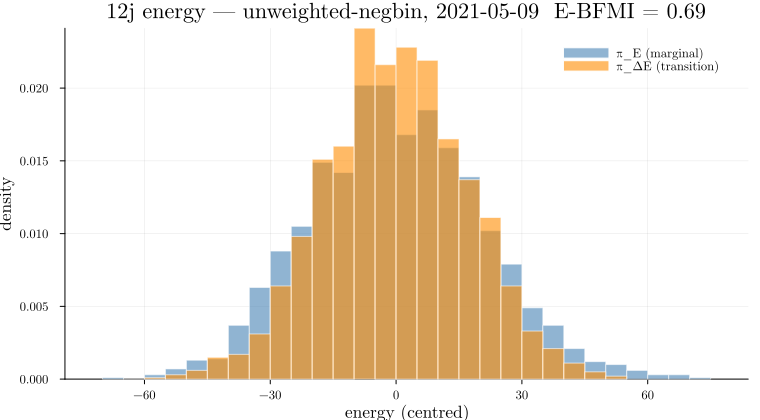

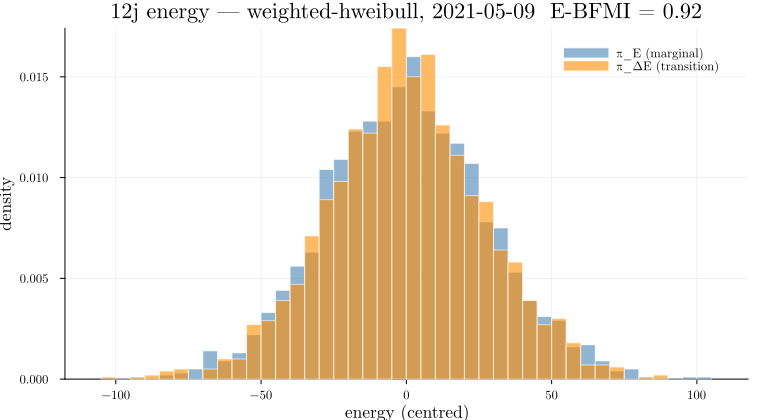

In [5]:
# Energy plot — π_E (marginal) vs π_ΔE (transition). A π_ΔE visibly narrower than π_E is the
# picture behind a low E-BFMI: the sampler cannot traverse the energy range the posterior occupies.
for d in DEGS
    p = plot_energy(CH[d].kept; title = "12j energy — $(d), $(ORIGIN)")
    p === nothing ? println("no hamiltonian_energy internal for $(d)") : display(p)
    p === nothing || savefig(p, "../res/12j_energy_$(d)_$(ORIGIN).png")
end

## §2 — Adaptation (warmup → sampling)

Only the **pilot** artefacts retain the warmup draws; a production fit discards them inside `sample` (`discard_initial = n_adapts`), so these panels are unavailable for the production grid and the cell below says so rather than failing.

What to look for at the dashed adaptation boundary:

- the **step size** stops moving (dual averaging finalises there — if it is still wandering afterwards something is wrong with the harness, not the model);
- the **tree depth falls**. A depth pinned at the cap *after* the boundary means the fit pays 2^`max_depth` gradients per iteration for the entire sampling phase, and that is the single biggest lever on the 504-fit grid cost.
- divergences (red) concentrated **in early warmup** are normal and harmless — the step size was still too large. Divergences after the boundary are not.

In [6]:
for d in DEGS
    p = plot_adaptation(CH[d].full, CH[d].n_adapt; title = "12j adaptation — $(d), $(ORIGIN)")
    if p === nothing
        println("warmup not retained for $(d) (production fits discard it) — skipping")
    else
        display(p); savefig(p, "../res/12j_adaptation_$(d)_$(ORIGIN).png")
    end
end

warmup not retained for unweighted-negbin (production fits discard it) — skipping
warmup not retained for weighted-hweibull (production fits discard it) — skipping


## §3 — Quantitative convergence over ALL parameters

389 (NegBin) and 977 (hurdle-Weibull) coordinates are far too many to inspect one at a time, so the primary read is **by parameter block**, reporting the **worst** coordinate in each rather than the mean — a block of 324 coordinates with median ESS 400 is not converged if one of them sits at 5.

The blocks come straight from `model_degree`:

| block | size | what it is |
|---|---|---|
| `c`, `log_eta`, `log_rho_diag`, `log_rho_gap`, `phi_time`, `log_sigma_c` | 1 each | shared GP scalars |
| `z_c` | `Tn`−1 = 11 | temporal-level raw (non-centred, sum-to-zero over weeks) |
| `z` | `(P−1) × Tn` = 27 × 12 = 324 | structure-field raw (non-centred, sum-to-zero) |
| `log_k` / `log_kappa` | 4 × 12 = 48 | dispersion, block-linear × week |
| `p0f` | 49 × 12 = 588 | fitted hurdle zero probability (**hurdle-Weibull only**) |

**Bulk and tail ESS are reported separately on purpose.** Bulk governs the posterior mean; tail governs the quantiles — and it is the tail that the forecast's 90% intervals and the WIS score actually depend on.

In [7]:
TBL = Dict(d => convergence_table(CH[d].kept) for d in DEGS)

for d in DEGS
    println("\n===== ", d, " — by parameter block (worst coordinate in each) =====")
    display(convergence_summary(TBL[d]))
end


===== unweighted-negbin — by parameter block (worst coordinate in each) =====

===== weighted-hweibull — by parameter block (worst coordinate in each) =====


Row,group,n,ess_bulk_min,ess_tail_min,rhat_max,n_low_ess,n_high_rhat
,String,Int64,Float64,Float64,Float64,Int64,Int64
1,log_rho_diag,1,286.467,754.481,1.01212,0,1
2,log_rho_gap,1,297.16,874.727,1.01227,0,1
3,log_sigma_c,1,326.996,656.916,1.00028,0,0
4,z_c,8,330.353,558.201,1.00102,0,0
5,log_eta,1,378.825,798.944,0.99995,0,0
6,phi_time,1,421.419,643.083,1.00011,0,0
7,z,243,548.325,940.22,1.00771,0,0
8,log_k,36,3957.63,939.408,1.00498,0,0
9,c,1,3971.17,1649.33,1.00443,0,0


Row,group,n,ess_bulk_min,ess_tail_min,rhat_max,n_low_ess,n_high_rhat
,String,Int64,Float64,Float64,Float64,Int64,Int64
1,log_sigma_c,1,389.84,775.704,1.00127,0,0
2,log_rho_diag,1,493.897,969.107,1.0062,0,0
3,log_rho_gap,1,507.006,1013.89,0.99997,0,0
4,log_eta,1,569.216,833.817,1.00258,0,0
5,z,243,611.312,773.634,1.01396,0,1
6,z_c,8,666.731,707.622,1.00354,0,0
7,phi_time,1,771.391,1300.73,0.999509,0,0
8,p0f,441,3291.79,792.015,1.01393,0,2
9,log_kappa,36,3907.99,927.341,1.00506,0,0


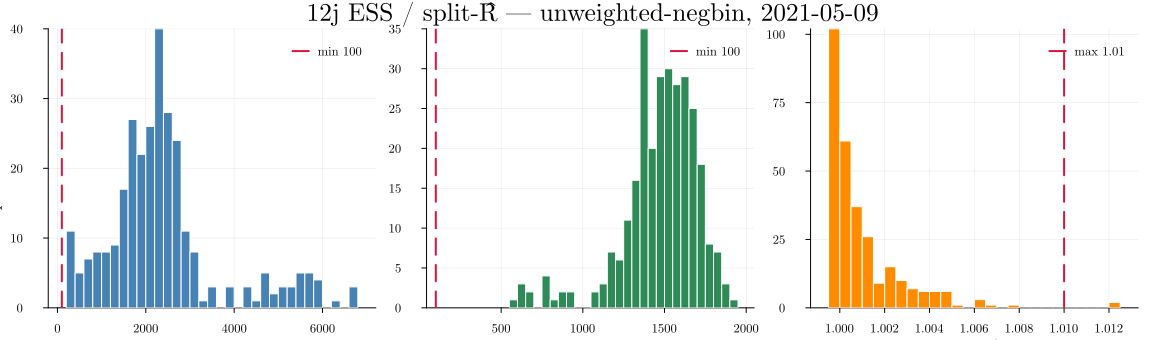

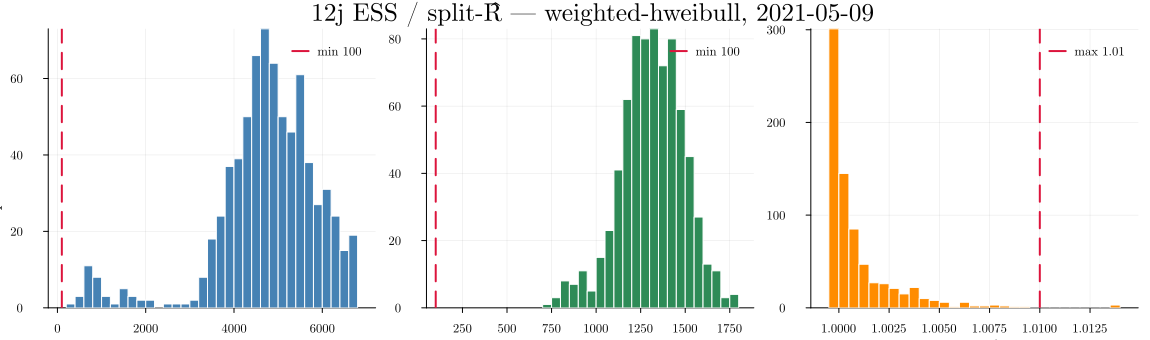

In [8]:
for d in DEGS
    p = plot_ess_rhat_dist(TBL[d]; title = "12j ESS / split-R̂ — $(d), $(ORIGIN)")
    display(p); savefig(p, "../res/12j_ess_rhat_$(d)_$(ORIGIN).png")
end

In [9]:
# The 15 worst coordinates by bulk ESS — these are the ones the block summary above is flagging.
for d in DEGS
    println("\n===== ", d, " — 15 worst coordinates by bulk ESS =====")
    display(first(sort(TBL[d], :ess_bulk), 15))
end


===== unweighted-negbin — 15 worst coordinates by bulk ESS =====

===== weighted-hweibull — 15 worst coordinates by bulk ESS =====


Row,parameter,group,mean,std,mcse,ess_bulk,ess_tail,rhat
,String,String,Float64,Float64,Float64,Float64,Float64,Float64
1,log_rho_diag,log_rho_diag,2.87393,0.188665,0.011413,286.467,754.481,1.01212
2,log_rho_gap,log_rho_gap,2.07606,0.146069,0.00843317,297.16,874.727,1.01227
3,log_sigma_c,log_sigma_c,-1.04203,0.304517,0.0165659,326.996,656.916,1.00028
4,z_c[2],z_c,1.0114,0.303623,0.0169947,330.353,558.201,1.00044
5,z_c[1],z_c,-0.826587,0.248785,0.0134664,350.872,611.412,1.00037
6,z_c[4],z_c,-0.862437,0.258057,0.0136941,363.903,770.054,1.00047
7,z_c[5],z_c,-0.631728,0.193288,0.0103107,368.484,870.678,1.00102
8,z_c[8],z_c,-0.49481,0.156166,0.0082456,371.052,601.347,1.00039
9,z_c[7],z_c,-0.423414,0.137385,0.00718161,375.421,792.023,1.00001


Row,parameter,group,mean,std,mcse,ess_bulk,ess_tail,rhat
,String,String,Float64,Float64,Float64,Float64,Float64,Float64
1,log_sigma_c,log_sigma_c,-1.80314,0.419934,0.0211596,389.84,775.704,1.00127
2,log_rho_diag,log_rho_diag,2.9467,0.220442,0.00989293,493.897,969.107,1.0062
3,log_rho_gap,log_rho_gap,2.5,0.208201,0.00925496,507.006,1013.89,0.99997
4,log_eta,log_eta,-0.635239,0.172344,0.00722358,569.216,833.817,1.00258
5,"z[23, 1]",z,0.464411,0.267541,0.0107853,611.312,1145.19,1.00096
6,"z[20, 1]",z,0.461183,0.279231,0.011117,624.802,1247.58,0.999585
7,"z[9, 1]",z,-0.69698,0.426968,0.0168807,641.727,1146.8,1.00433
8,"z[5, 1]",z,1.28804,0.25561,0.0100335,643.611,1075.09,1.00193
9,z_c[8],z_c,0.39878,0.197713,0.00802946,666.731,1198.13,1.00354


## §4 — Visual convergence

Three views of the same thing, on the six shared GP scalars (the coordinates that are genuinely *shared* across all 49 age-pair cells and all 12 weeks, so they are both the best identified and the ones whose failure would contaminate everything downstream):

1. **Trace + running mean.** The running mean is the point — a raw trace of 500 correlated draws is hard to read, but a running mean still drifting at the end of the chain is unambiguous. It is the visual counterpart of split-R̂.
2. **Rank plots** (Vehtari 2021), the recommended replacement for trace plots. Ranks are pooled over the chain, then histogrammed per consecutive segment; a stationary chain gives four flat histograms sitting on the dashed line. Skew in one segment localises *where* in the chain the drift was.
3. **Autocorrelation**, which reads directly as sampling efficiency — ESS ≈ N/(1+2Σρ), so an ACF still above the ±2/√N band at lag 50 means that parameter contributes a small fraction of its nominal 500 draws.

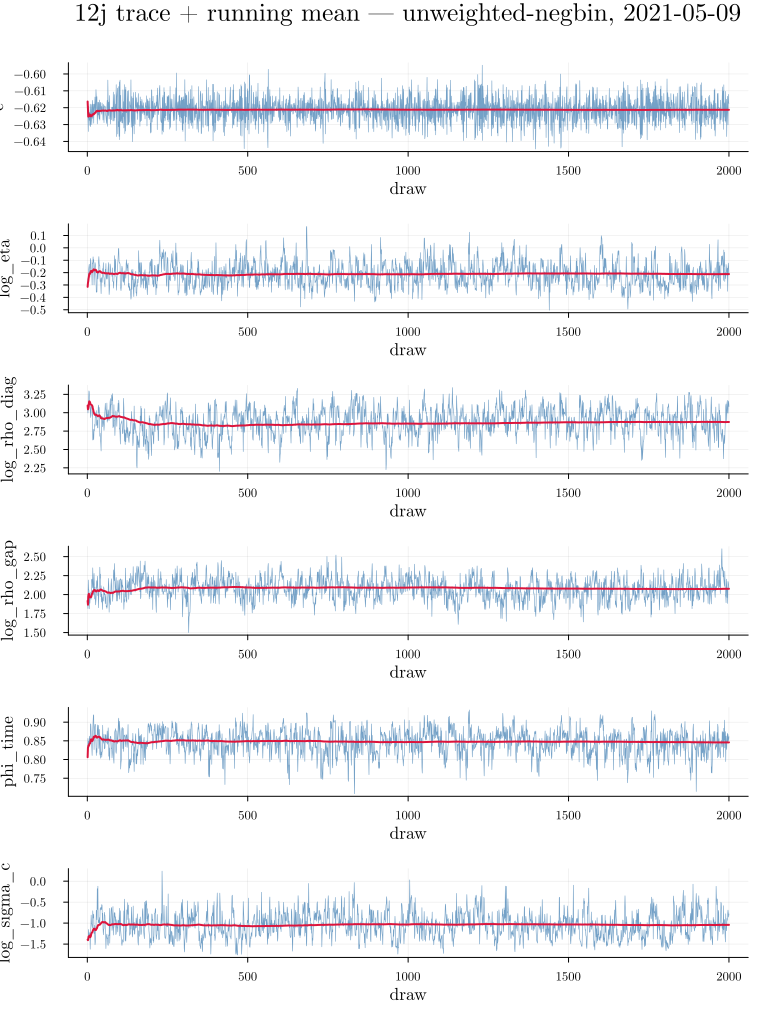

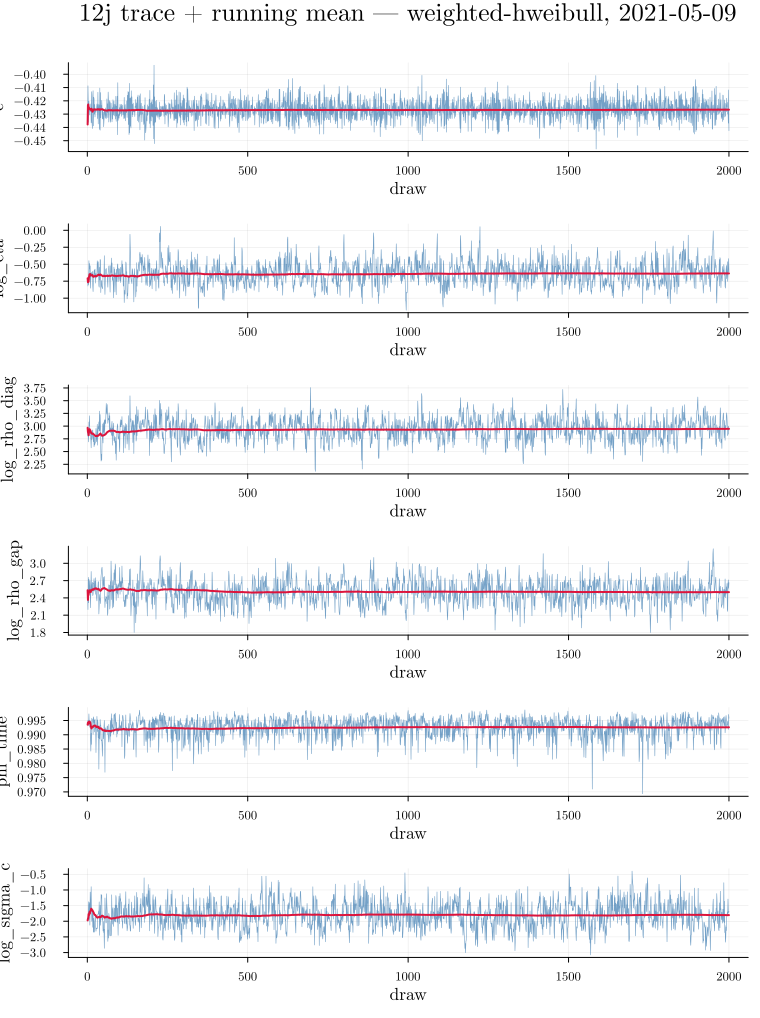

In [10]:
SCALARS = [:c, :log_eta, :log_rho_diag, :log_rho_gap, :phi_time, :log_sigma_c]

for d in DEGS
    p = plot_trace_running(CH[d].kept, SCALARS; title = "12j trace + running mean — $(d), $(ORIGIN)")
    display(p); savefig(p, "../res/12j_trace_$(d)_$(ORIGIN).png")
end

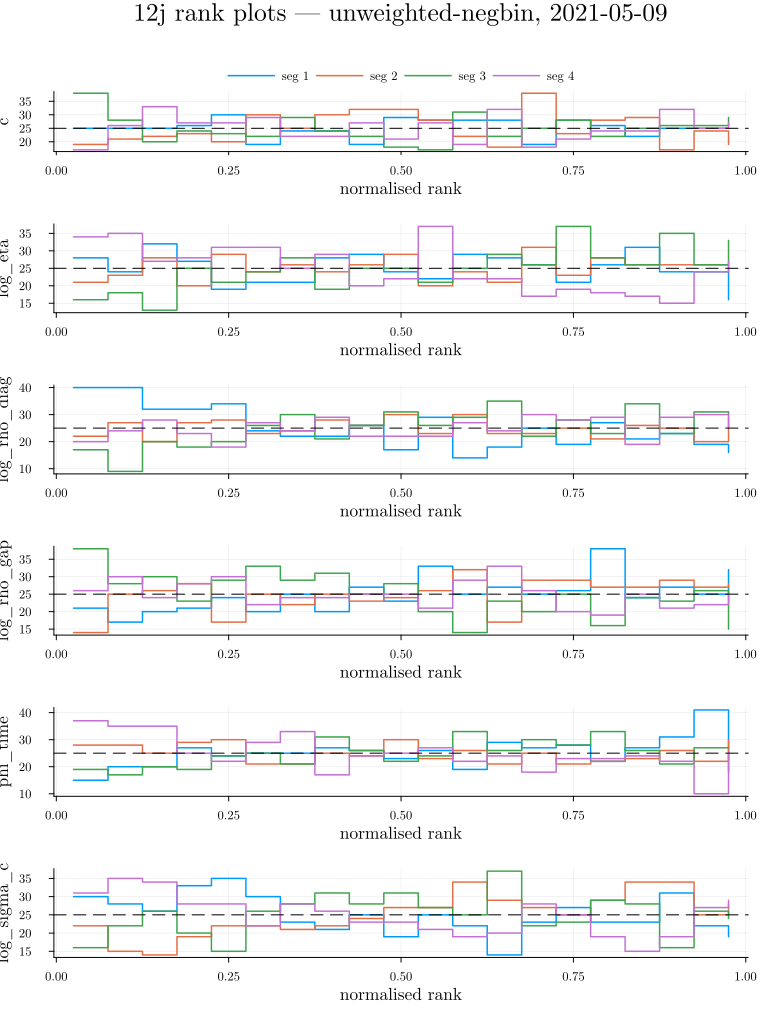

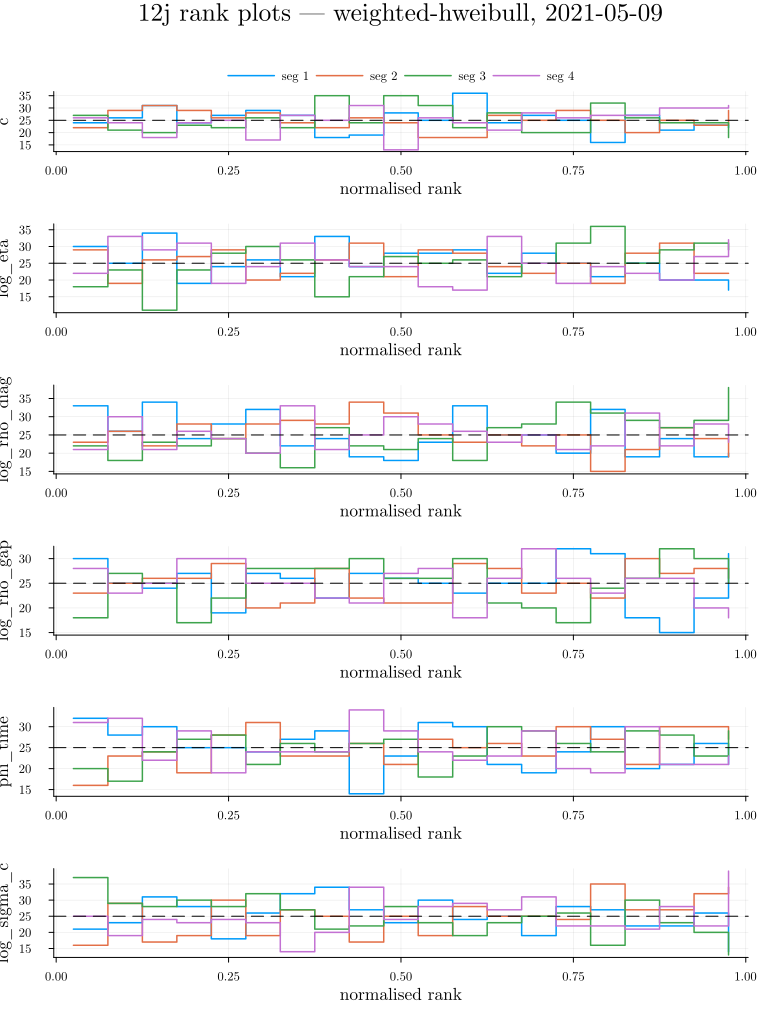

In [11]:
for d in DEGS
    p = plot_rank(CH[d].kept, SCALARS; nsplit = 4,
                  title = "12j rank plots — $(d), $(ORIGIN)")
    display(p); savefig(p, "../res/12j_rank_$(d)_$(ORIGIN).png")
end

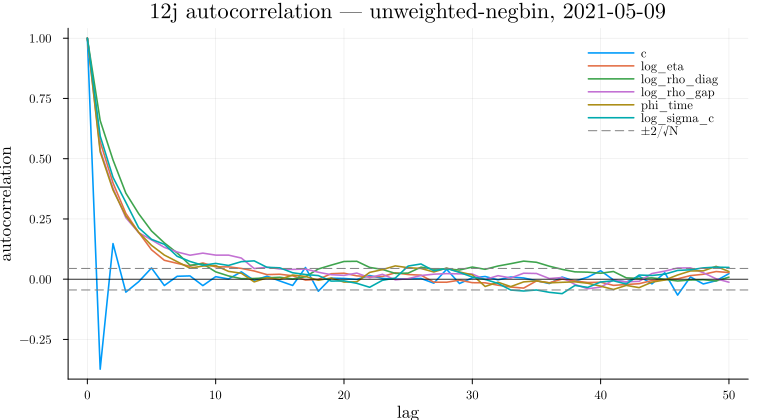

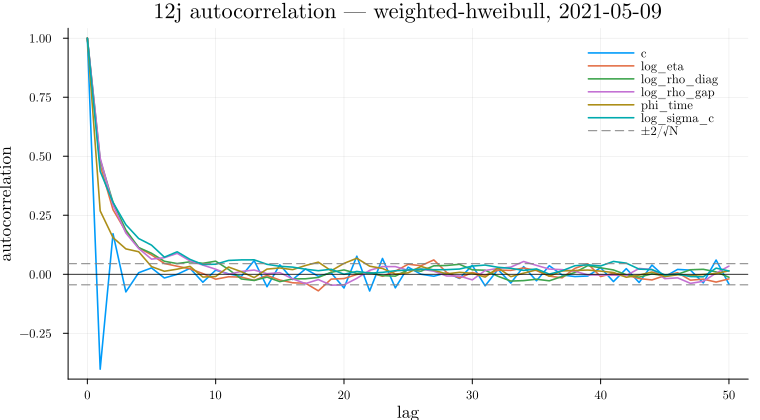

In [12]:
for d in DEGS
    p = plot_acf(CH[d].kept, SCALARS; maxlag = 50, title = "12j autocorrelation — $(d), $(ORIGIN)")
    display(p); savefig(p, "../res/12j_acf_$(d)_$(ORIGIN).png")
end

## §5 — Where the divergences are

`model_degree` is **non-centred throughout** (`z ~ filldist(Normal(0,1), P, Tn)`, `z_c ~ filldist(Normal(0,1), Tn)`) — precisely the reparameterisation that removes the funnel between a scale parameter and the raw variates it multiplies. These pairs are the check that it did its job.

Divergences that **cluster** in one region — classically the neck of a funnel, e.g. small `log_sigma_c` against large `z_c` — localise geometry the sampler could not handle and point at a parameterisation fix. Divergences **scattered** across the pair usually just mean the step size is slightly too large, which `target_accept` handles. An empty plot means zero divergences in the kept draws, which is the outcome to hope for.

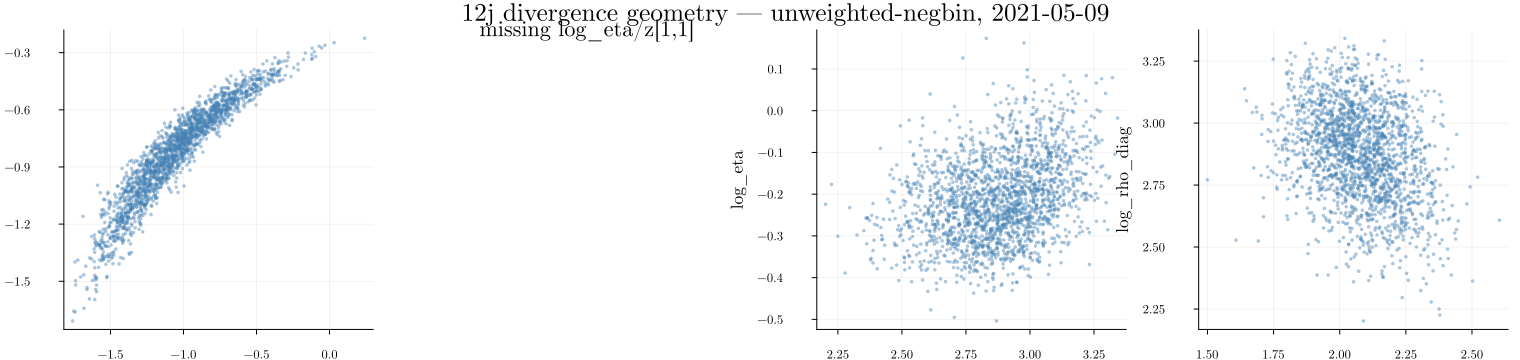

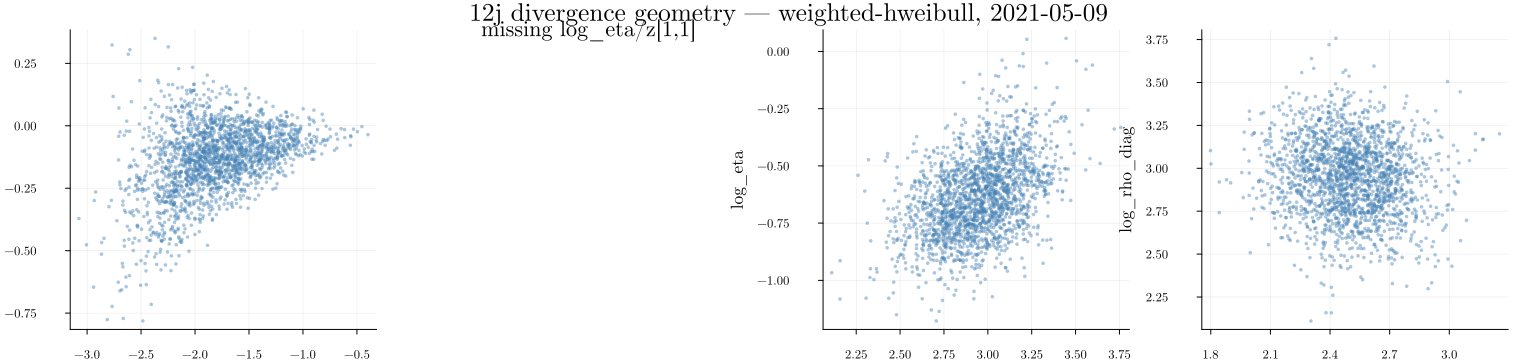

In [13]:
PAIRS = [(:log_sigma_c, Symbol("z_c[1]")), (:log_eta, Symbol("z[1,1]")), (:log_rho_diag, :log_eta),
         (:log_rho_gap, :log_rho_diag)]

for d in DEGS
    p = plot_divergence_pairs(CH[d].kept, PAIRS; title = "12j divergence geometry — $(d), $(ORIGIN)")
    display(p); savefig(p, "../res/12j_divpairs_$(d)_$(ORIGIN).png")
end

## §6 — Verdict

One pass/fail block per model. The checks, in the order that matters: divergences in the kept draws (hard fail — those draws are biased), E-BFMI ≥ 0.3, split-R̂ ≤ 1.01 everywhere, bulk and tail ESS ≥ 100 everywhere.

`frac_at_max` is printed but is deliberately **not** a failure condition: a saturated tree costs gradients, it does not invalidate draws. It belongs to the cost question (`tasks/todo.md`), not the correctness one.

In [14]:
VERDICT = Dict(d => convergence_verdict(d, HH[d], TBL[d]) for d in DEGS)
println()
println(all(values(VERDICT)) ? "ALL MODELS PASS at $(ORIGIN)" :
        "NOT CONVERGED: " * join([d for d in DEGS if !VERDICT[d]], ", "))

── convergence verdict: unweighted-negbin ─────────────────────────────
  PASS  divergences in kept draws : 0
  PASS  E-BFMI >= 0.3             : 0.69
  FAIL  split-R̂ <= 1.01           : 2 of 293 parameters above
  PASS  ESS >= 100 (bulk & tail)   : 0 of 586 checks below
  ····  tree depth 7.00 (deepest built 7, 100% of iterations there; 0% at the cap), accept 0.941, 254000.0 gradients
── convergence verdict: weighted-hweibull ─────────────────────────────
  PASS  divergences in kept draws : 0
  PASS  E-BFMI >= 0.3             : 0.92
  FAIL  split-R̂ <= 1.01           : 3 of 734 parameters above
  PASS  ESS >= 100 (bulk & tail)   : 0 of 1468 checks below
  ····  tree depth 7.00 (deepest built 7, 100% of iterations there; 0% at the cap), accept 0.948, 254000.0 gradients

NOT CONVERGED: unweighted-negbin, weighted-hweibull
